读取文件: /data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train/case1_c1472_f001472-001536.txt
加载帧完成，frames.shape = (64, 320, 568)
运动密度计算完成。


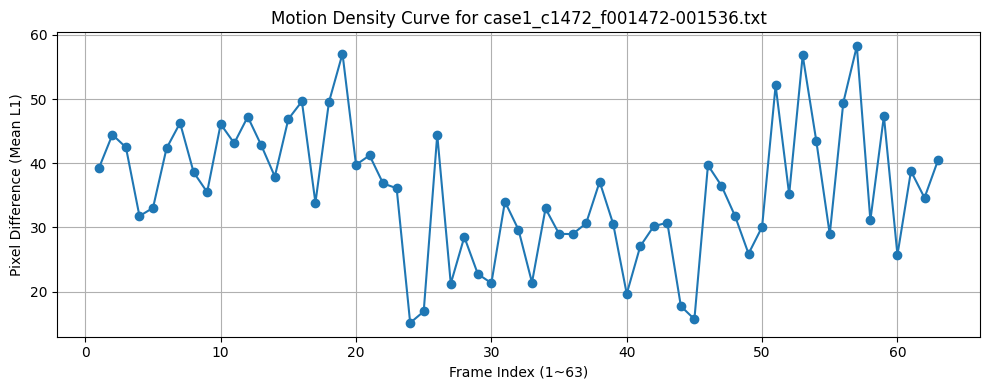

In [12]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 让matplotlib自动在notebook中显示
%matplotlib inline

import sys
sys.path.append('/data/wjl/vjepa2')

# 设置clips目录
clips_dir = '/data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train'

### 2. 设置路径与随机选择一个txt文件
# 随机选择一个txt文件
txt_files = [f for f in os.listdir(clips_dir) if f.endswith('.txt')]
if not txt_files:
    raise RuntimeError("未找到任何txt文件")
random_txt = random.choice(txt_files)
txt_path = os.path.join(clips_dir, random_txt)
print(f"读取文件: {txt_path}")


## 3. 读取图片路径并加载图片
# 读取64帧图像路径
with open(txt_path) as f:
    img_paths = [line.strip() for line in f.readlines() if line.strip()]

assert len(img_paths) == 64, f"文件帧数不是64，而是{len(img_paths)}"

# 依次读取图片
frames = []
for img_path in img_paths:
    img_path = os.path.join("/data/wjl/vjepa2", img_path)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # 灰度读入
    if img is None:
        raise RuntimeError(f"图片读取失败: {img_path}")
    frames.append(img.astype(np.float32))

frames = np.stack(frames, axis=0)  # 形状 (64, H, W)
print(f"加载帧完成，frames.shape = {frames.shape}")

## 4. 计算帧间像素差（运动密度）

motion_density = []
for t in range(frames.shape[0] - 1):
    diff = np.abs(frames[t+1] - frames[t])
    density = np.mean(diff)
    motion_density.append(density)

print("运动密度计算完成。")

plt.figure(figsize=(10, 4))
plt.plot(range(1, 64), motion_density, marker='o')
plt.title(f'Motion Density Curve for {random_txt}')
plt.xlabel('Frame Index (1~63)')
plt.ylabel('Pixel Difference (Mean L1)')
plt.grid(True)
plt.tight_layout()
plt.show()




In [14]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 随机读取一个txt文件并加载64帧
clips_dir = '/data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train'
txt_files = [f for f in os.listdir(clips_dir) if f.endswith('.txt')]
if not txt_files:
    raise RuntimeError("未找到任何txt文件")
random_txt = random.choice(txt_files)
txt_path = os.path.join(clips_dir, random_txt)
print(f"读取文件: {txt_path}")

with open(txt_path) as f:
    img_paths = [line.strip() for line in f.readlines() if line.strip()]
assert len(img_paths) == 64, f"文件帧数不是64，而是{len(img_paths)}"

frames = []
for img_path in img_paths:
    if not os.path.isabs(img_path):
        img_path = os.path.join("/data/wjl/vjepa2", img_path)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"图片读取失败: {img_path}")
    frames.append(img.astype(np.float32))
frames = np.stack(frames, axis=0)  # (64, H, W)
print(f"加载帧完成，frames.shape = {frames.shape}")

# 运动密度
motion_density = []
for t in range(frames.shape[0] - 1):
    diff = np.abs(frames[t+1] - frames[t])
    density = np.mean(diff)
    motion_density.append(density)

# 改进的make_grid函数，提升对比度
def make_grid(frames, grid_size=(8,8)):
    H, W = frames[0].shape
    grid_img = np.zeros((grid_size[0]*H, grid_size[1]*W), dtype=np.float32)
    for idx, frame in enumerate(frames):
        i = idx // grid_size[1]
        j = idx % grid_size[1]
        # 归一化每一帧，增强对比度
        frame_norm = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX)
        grid_img[i*H:(i+1)*H, j*W:(j+1)*W] = frame_norm
    # 不建议再全局归一化，这样单帧对比度最高
    return grid_img.astype(np.uint8)

grid_img = make_grid(frames, grid_size=(8,8))

# 保存
os.makedirs('logs8', exist_ok=True)
out_png = os.path.join('logs8', f"{os.path.splitext(random_txt)[0]}_frames_and_density.png")

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.0, 1.5], wspace=0.15)

# 左侧帧网格
ax1 = fig.add_subplot(gs[0])
ax1.imshow(grid_img, cmap='gray', vmin=0, vmax=255)
ax1.set_title('64 Frames Grid', fontsize=14)
ax1.axis('off')

# 右侧运动密度曲线
ax2 = fig.add_subplot(gs[1])
ax2.plot(range(1, 64), motion_density, marker='o', linewidth=2)
ax2.set_title('Motion Density Curve', fontsize=14)
ax2.set_xlabel('Frame Index (1~63)', fontsize=12)
ax2.set_ylabel('Pixel Difference (Mean L1)', fontsize=12)
ax2.grid(True)

fig.suptitle(f'{random_txt} — 64 frames & motion density', fontsize=18, y=0.98)
plt.savefig(out_png, dpi=180, bbox_inches='tight')
plt.close(fig)

print(f"已保存到: {out_png}")

读取文件: /data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train/case4_c763_f000763-000827.txt
加载帧完成，frames.shape = (64, 320, 568)


已保存到: logs8/case4_c763_f000763-000827_frames_and_density.png


In [16]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 随机读取一个txt文件并加载64帧（彩色）
clips_dir = '/data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train'
txt_files = [f for f in os.listdir(clips_dir) if f.endswith('.txt')]
if not txt_files:
    raise RuntimeError("未找到任何txt文件")
random_txt = random.choice(txt_files)
txt_path = os.path.join(clips_dir, random_txt)
print(f"读取文件: {txt_path}")

with open(txt_path) as f:
    img_paths = [line.strip() for line in f.readlines() if line.strip()]
assert len(img_paths) == 64, f"文件帧数不是64，而是{len(img_paths)}"

frames = []
for img_path in img_paths:
    if not os.path.isabs(img_path):
        img_path = os.path.join("/data/wjl/vjepa2", img_path)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # 彩色读入
    if img is None:
        raise RuntimeError(f"图片读取失败: {img_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    frames.append(img_rgb.astype(np.float32))
frames = np.stack(frames, axis=0)  # (64, H, W, 3)
print(f"加载帧完成，frames.shape = {frames.shape}")

# 运动密度（对RGB三通道平均）
motion_density = []
for t in range(frames.shape[0] - 1):
    diff = np.abs(frames[t+1] - frames[t])
    density = np.mean(diff)
    motion_density.append(density)

# 彩色make_grid函数
def make_grid_color(frames, grid_size=(8,8)):
    H, W, C = frames[0].shape
    grid_img = np.zeros((grid_size[0]*H, grid_size[1]*W, C), dtype=np.float32)
    for idx, frame in enumerate(frames):
        i = idx // grid_size[1]
        j = idx % grid_size[1]
        # 归一化每一帧
        frame_norm = np.zeros_like(frame)
        for c in range(C):
            frame_norm[..., c] = cv2.normalize(frame[..., c], None, 0, 255, cv2.NORM_MINMAX)
        grid_img[i*H:(i+1)*H, j*W:(j+1)*W, :] = frame_norm
    return grid_img.astype(np.uint8)

grid_img = make_grid_color(frames, grid_size=(8,8))

# 保存
os.makedirs('logs8', exist_ok=True)
out_png = os.path.join('logs8', f"{os.path.splitext(random_txt)[0]}_frames_and_density_v_rgb.png")

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[2.3, 1], hspace=0.12)

# 上方帧网格（彩色）
ax1 = fig.add_subplot(gs[0])
ax1.imshow(grid_img)
ax1.set_title('64 Frames Grid (Color)', fontsize=14)
ax1.axis('off')

# 下方运动密度曲线
ax2 = fig.add_subplot(gs[1])
ax2.plot(range(1, 64), motion_density, marker='o', linewidth=2)
ax2.set_title('Motion Density Curve', fontsize=14)
ax2.set_xlabel('Frame Index (1~63)', fontsize=12)
ax2.set_ylabel('Pixel Difference (Mean L1)', fontsize=12)
ax2.grid(True)

fig.suptitle(f'{random_txt} — 64 frames & motion density', fontsize=18, y=0.99)
plt.savefig(out_png, dpi=180, bbox_inches='tight')
plt.close(fig)

print(f"已保存到: {out_png}")


读取文件: /data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train/case4_c2332_f002332-002396.txt
加载帧完成，frames.shape = (64, 320, 568, 3)
已保存到: logs8/case4_c2332_f002332-002396_frames_and_density_v_rgb.png


AttributeError: 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

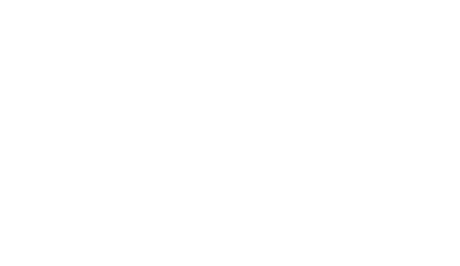

In [19]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

# 1. 读取帧
clips_dir = '/data/wjl/vjepa2/data/Surge_Frames/AutoLaparo/clips_64f/clip_dense_64f_info/train'
txt_files = [f for f in os.listdir(clips_dir) if f.endswith('.txt')]
random_txt = random.choice(txt_files)
txt_path = os.path.join(clips_dir, random_txt)
with open(txt_path) as f:
    img_paths = [line.strip() for line in f.readlines() if line.strip()]
assert len(img_paths) == 64

frames = []
for img_path in img_paths:
    if not os.path.isabs(img_path):
        img_path = os.path.join("/data/wjl/vjepa2", img_path)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    frames.append(img_rgb)
frames = np.stack(frames, axis=0)  # (64, H, W, 3)
H, W, C = frames[0].shape

# 2. 运动密度
motion_density = []
for t in range(frames.shape[0] - 1):
    diff = np.abs(frames[t+1].astype(np.float32) - frames[t].astype(np.float32))
    density = np.mean(diff)
    motion_density.append(density)
motion_density = np.array(motion_density)

# 3. 生成每帧的小密度曲线图
def plot_mini_curve(motion_density, up_to, height, width):
    fig = plt.figure(figsize=(width/100, height/100), dpi=100)
    plt.plot(range(1, up_to+2), motion_density[:up_to+1], color='b')
    plt.xlim(0, 64)
    plt.ylim(0, max(motion_density)*1.05)
    plt.axis('off')
    canvas = FigureCanvas(fig)
    canvas.draw()
    img = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return img

mini_w = W  # 保持和原帧一样宽

mini_curve_imgs = []
for i in range(64):
    if i == 0:
        mini_curve = plot_mini_curve(motion_density, 0, H, mini_w)
    else:
        mini_curve = plot_mini_curve(motion_density, i-1, H, mini_w)
    if mini_curve.shape[0] != H or mini_curve.shape[1] != mini_w:
        mini_curve = cv2.resize(mini_curve, (mini_w, H), interpolation=cv2.INTER_AREA)
    mini_curve_imgs.append(mini_curve)

# 4. 交替拼成大图（每8帧为一行）
rows = []
for row_block in range(8):  # 8行，每行8对（原图+小曲线）
    for sub_row in range(2):  # 0:手术帧，1:小曲线
        row_imgs = []
        for col in range(8):
            idx = row_block * 8 + col
            if sub_row == 0:  # 奇数行：帧
                row_imgs.append(frames[idx])
            else:             # 偶数行：密度曲线
                row_imgs.append(mini_curve_imgs[idx])
        row_cat = np.concatenate(row_imgs, axis=1)
        rows.append(row_cat)
big_img = np.concatenate(rows, axis=0)

# 5. 保存为彩色大图
os.makedirs('logs8', exist_ok=True)
out_png = os.path.join('logs8', f"{os.path.splitext(random_txt)[0]}_interleave_frame_curve.png")
plt.imsave(out_png, big_img)
print(f"已保存到: {out_png}")

